# 07 - Anomalib Model Training

This notebook trains a professional anomaly detection model for VisionInspect AI using **PyTorch + Anomalib**.

We will start with **PaDiM** because it is usually fast, stable, and suitable for industrial anomaly detection on MVTec AD.

## Goal

Train a model that can inspect a bottle image and produce:

- image-level anomaly score
- good/defective prediction
- pixel-level anomaly map / heatmap
- evaluation metrics such as image AUROC and pixel AUROC

This model will later connect to the FastAPI backend.

## Important Note

The previous notebook built a classical baseline. This notebook is the stronger professional model.

Recommended progression:

1. Train PaDiM first.
2. Compare with PatchCore later.
3. Export the best model for backend inference.

In [1]:
from pathlib import Path
import json
import shutil
import sys

import cv2
import matplotlib.pyplot as plt
import pandas as pd
import torch
from torchvision.transforms import v2

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from anomalib.data import MVTecAD
from anomalib.deploy import ExportType
from anomalib.engine import Engine
from anomalib.models import Fastflow, Padim, Patchcore

from ml.dataset_loader import load_bottle_dataframe

DATA_ROOT = PROJECT_ROOT / "data" / "raw" / "mvtec_anomaly_detection"
RESULTS_DIR = PROJECT_ROOT / "outputs" / "anomalib_training"
REPORT_DIR = PROJECT_ROOT / "outputs" / "reports"
MODEL_CHECKPOINT_DIR = PROJECT_ROOT / "models" / "checkpoints"
MODEL_EXPORT_DIR = PROJECT_ROOT / "models" / "exported"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Dataset root:", DATA_ROOT)
print("Results dir:", RESULTS_DIR)

W0703 03:37:17.265000 32352 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
C:\Users\HP\anaconda3\Lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Project root: C:\Users\HP\Desktop\springboard\visioninspect-ai
Dataset root: C:\Users\HP\Desktop\springboard\visioninspect-ai\data\raw\mvtec_anomaly_detection
Results dir: C:\Users\HP\Desktop\springboard\visioninspect-ai\outputs\anomalib_training


## GPU Check

Training should use your local RTX 4050 if CUDA is available.

In [2]:
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
    torch.set_float32_matmul_precision("medium")
else:
    print("GPU not available. Training will run on CPU and may be slow.")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
CUDA version: 12.8


## Training Configuration

For the first professional run, use conservative settings that fit your 6 GB RTX 4050.

You can later increase image size, batch size, or try PatchCore.

In [3]:
MODEL_NAME = "padim"  # options later: padim, patchcore, fastflow
CATEGORY = "bottle"
IMAGE_SIZE = (256, 256)
TRAIN_BATCH_SIZE = 4
EVAL_BATCH_SIZE = 4

# On Windows notebooks, num_workers=0 is the most stable option.
NUM_WORKERS = 0

ACCELERATOR = "gpu" if torch.cuda.is_available() else "cpu"
DEVICES = 1
MAX_EPOCHS = 1

RUN_TRAINING = True
RUN_EXPORT_ONNX = False

print("Model:", MODEL_NAME)
print("Image size:", IMAGE_SIZE)
print("Accelerator:", ACCELERATOR)

Model: padim
Image size: (256, 256)
Accelerator: gpu


## Verify Dataset Metadata

Before training, confirm the dataset loader sees the expected records.

In [4]:
dataset_df = load_bottle_dataframe()

print("Total image records:", len(dataset_df))
display(dataset_df.groupby(["split", "label", "target_name"]).size().reset_index(name="count"))

if len(dataset_df) == 0:
    raise RuntimeError("Dataset is empty. Check the MVTec bottle folder path.")

Total image records: 292


,split,label,target_name,count
0,test,broken_large,defective,20
1,test,broken_small,defective,22
2,test,contamination,defective,21
3,test,good,good,20
4,train,good,good,209


## Create Anomalib DataModule

Anomalib expects the MVTec root folder that contains the `bottle/` category folder.

We resize images to `256 x 256` so training fits comfortably on your GPU.

In [5]:
augmentations = v2.Compose([
    v2.Resize(IMAGE_SIZE, antialias=True),
])

datamodule = MVTecAD(
    root=DATA_ROOT,
    category=CATEGORY,
    train_batch_size=TRAIN_BATCH_SIZE,
    eval_batch_size=EVAL_BATCH_SIZE,
    num_workers=NUM_WORKERS,
    augmentations=augmentations,
)

datamodule.setup()

print("Train images:", len(datamodule.train_data))
print("Validation images:", len(datamodule.val_data))
print("Test images:", len(datamodule.test_data))

Train images: 209
Validation images: 83
Test images: 83


## Inspect A Batch

This confirms image tensors are resized correctly and labels are present.

In [6]:
batch = next(iter(datamodule.train_dataloader()))

print("Batch image shape:", batch.image.shape)
print("Batch labels:", batch.gt_label)
print("First image path:", batch.image_path[0])

Batch image shape: torch.Size([4, 3, 256, 256])
Batch labels: tensor([False, False, False, False])
First image path: C:\Users\HP\Desktop\springboard\visioninspect-ai\data\raw\mvtec_anomaly_detection\bottle/train/good/042.png


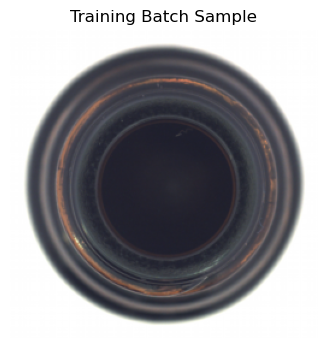

In [7]:
def show_tensor_image(tensor_image, title="Image"):
    image = tensor_image.detach().cpu()
    image = image.permute(1, 2, 0).numpy()
    image = image.clip(0, 1)

    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.title(title)
    plt.axis("off")
    plt.show()


show_tensor_image(batch.image[0], "Training Batch Sample")

## Build Model

Start with PaDiM using ResNet18 features.

For your RTX 4050, `n_features=100` keeps memory and runtime reasonable.

In [8]:
def build_model(model_name):
    model_name = model_name.lower()

    if model_name == "padim":
        return Padim(
            backbone="resnet18",
            layers=["layer1", "layer2", "layer3"],
            pre_trained=True,
            n_features=100,
        )

    if model_name == "patchcore":
        return Patchcore(
            backbone="wide_resnet50_2",
            layers=("layer2", "layer3"),
            pre_trained=True,
            coreset_sampling_ratio=0.05,
            num_neighbors=5,
        )

    if model_name == "fastflow":
        return Fastflow(
            backbone="resnet18",
            pre_trained=True,
            flow_steps=8,
        )

    raise ValueError(f"Unsupported model: {model_name}")


model = build_model(MODEL_NAME)
model

Padim(
  (pre_processor): PreProcessor(
    (transform): Compose(
          Resize(size=[256, 256], interpolation=InterpolationMode.BILINEAR, antialias=True)
          Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
    )
    (export_transform): Compose(
          Resize(size=[256, 256], interpolation=InterpolationMode.BILINEAR, antialias=False)
          Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
    )
  )
  (post_processor): PostProcessor(
    (_image_threshold_metric): F1AdaptiveThreshold()
    (_pixel_threshold_metric): F1AdaptiveThreshold()
    (_image_min_max_metric): MinMax()
    (_pixel_min_max_metric): MinMax()
  )
  (evaluator): Evaluator(
    (val_metrics): ModuleList()
    (test_metrics): ModuleList(
      (0): AUROC()
      (1): F1Score()
      (2): AUROC()
      (3): F1Score()
    )
  )
  (model): PadimModel(
    (feature_extractor): TimmFeatureExtractor(
      (feature_extractor): FeatureListNet(
      

## Build Engine

Anomalib's `Engine` wraps PyTorch Lightning training/testing.

The output folder will contain checkpoints, logs, and generated visualizations.

In [9]:
engine = Engine(
    accelerator=ACCELERATOR,
    devices=DEVICES,
    max_epochs=MAX_EPOCHS,
    default_root_dir=RESULTS_DIR,
    logger=False,
)

engine

## Train Model

First training run may download pretrained ResNet weights.

Expected time on RTX 4050 for PaDiM at `256 x 256`: usually a few minutes or less.

In [10]:
if RUN_TRAINING:
    engine.fit(model=model, datamodule=datamodule)
else:
    print("RUN_TRAINING is False. Skipping training.")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
`Trainer(val_check_interval=1.0)` was configured so validation will run at the end of the training epoch..
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
C:\Users\HP\anaconda3\Lib\site-packages\lightning\pytorch\core\optimizer.py:183: `LightningModule.configure_optimizers` returned `None`, this fit will run with no optimizer


┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ pre_processor  │ PreProcessor  │      0 │ train │     0 │
│ 1 │ post_processor │ PostProcessor │      0 │ train │     0 │
│ 2 │ evaluator      │ Evaluator     │      0 │ train │     0 │
│ 3 │ model          │ PadimModel    │  2.8 M │ train │     0 │
└───┴────────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.8 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.8 M                                                                                                
Total estimated model params size (MB): 11.131                                                                     
Modules in train mode: 19                                                                                          
Modules in eval mode: 69                                                                                           
Total FLOPs: 0

Output()

C:\Users\HP\anaconda3\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\HP\anaconda3\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
C:\Users\HP\anaconda3\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
C:\Users\HP\anaconda3\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:538: Found 69 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If th

## Test Model

Testing computes image-level and pixel-level metrics.

Important metrics:

- `image_AUROC`: good vs defective classification quality
- `pixel_AUROC`: defect localization / heatmap quality
- `image_F1Score`
- `pixel_F1Score`

In [11]:
test_results = engine.test(model=model, datamodule=datamodule)
test_results

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: Evaluator, ImageVisualizer, PostProcessor, PreProcessor
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

C:\Users\HP\anaconda3\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\HP\anaconda3\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│        image_AUROC        │            1.0            │
│       image_F1Score       │    0.9919999837875366     │
│        pixel_AUROC        │    0.9787426590919495     │
│       pixel_F1Score       │    0.6798816919326782     │
└───────────────────────────┴───────────────────────────┘

[{'image_AUROC': 1.0,
  'image_F1Score': 0.9919999837875366,
  'pixel_AUROC': 0.9787426590919495,
  'pixel_F1Score': 0.6798816919326782}]

## Save Metrics

Save metrics for the final report and model card.

In [12]:
metrics = test_results[0] if test_results else {}
metrics = {key: float(value) for key, value in metrics.items()}

metrics_path = REPORT_DIR / "anomalib_padim_metrics.json"
with metrics_path.open("w", encoding="utf-8") as file:
    json.dump(metrics, file, indent=2)

print("Saved metrics:", metrics_path)
metrics

Saved metrics: C:\Users\HP\Desktop\springboard\visioninspect-ai\outputs\reports\anomalib_padim_metrics.json


{'image_AUROC': 1.0,
 'image_F1Score': 0.9919999837875366,
 'pixel_AUROC': 0.9787426590919495,
 'pixel_F1Score': 0.6798816919326782}

## Locate And Copy Checkpoint

Anomalib saves checkpoints under the results folder. We copy the best/latest checkpoint into `models/checkpoints/` for final project use.

In [13]:
checkpoint_candidates = sorted(RESULTS_DIR.rglob("*.ckpt"), key=lambda path: path.stat().st_mtime, reverse=True)

if checkpoint_candidates:
    source_checkpoint = checkpoint_candidates[0]
    final_checkpoint = MODEL_CHECKPOINT_DIR / f"{MODEL_NAME}_mvtec_bottle_v1.ckpt"
    shutil.copy2(source_checkpoint, final_checkpoint)
    print("Source checkpoint:", source_checkpoint)
    print("Copied checkpoint:", final_checkpoint)
else:
    final_checkpoint = None
    print("No checkpoint found yet.")

Source checkpoint: C:\Users\HP\Desktop\springboard\visioninspect-ai\outputs\anomalib_training\Padim\MVTecAD\bottle\v1\weights\lightning\model.ckpt
Copied checkpoint: C:\Users\HP\Desktop\springboard\visioninspect-ai\models\checkpoints\padim_mvtec_bottle_v1.ckpt


## Save Model Metadata

This JSON file documents what model was trained and where it is stored.

In [14]:
metadata = {
    "project": "VisionInspect AI",
    "model_name": MODEL_NAME,
    "model_version": "v1",
    "dataset": "MVTec AD bottle",
    "category": CATEGORY,
    "image_size": list(IMAGE_SIZE),
    "train_batch_size": TRAIN_BATCH_SIZE,
    "eval_batch_size": EVAL_BATCH_SIZE,
    "accelerator": ACCELERATOR,
    "checkpoint_path": str(final_checkpoint) if final_checkpoint else None,
    "metrics": metrics,
}

metadata_path = PROJECT_ROOT / "models" / "model_metadata.json"
with metadata_path.open("w", encoding="utf-8") as file:
    json.dump(metadata, file, indent=2)

print("Saved metadata:", metadata_path)
metadata

Saved metadata: C:\Users\HP\Desktop\springboard\visioninspect-ai\models\model_metadata.json


{'project': 'VisionInspect AI',
 'model_name': 'padim',
 'model_version': 'v1',
 'dataset': 'MVTec AD bottle',
 'category': 'bottle',
 'image_size': [256, 256],
 'train_batch_size': 4,
 'eval_batch_size': 4,
 'accelerator': 'gpu',
 'checkpoint_path': 'C:\\Users\\HP\\Desktop\\springboard\\visioninspect-ai\\models\\checkpoints\\padim_mvtec_bottle_v1.ckpt',
 'metrics': {'image_AUROC': 1.0,
  'image_F1Score': 0.9919999837875366,
  'pixel_AUROC': 0.9787426590919495,
  'pixel_F1Score': 0.6798816919326782}}

## Inspect Generated Visualizations

Anomalib saves heatmap visualization images inside the results directory during testing.

In [15]:
visualization_files = sorted(RESULTS_DIR.rglob("*.png"))
print("Visualization files found:", len(visualization_files))

for path in visualization_files[:10]:
    print(path)

Visualization files found: 249
C:\Users\HP\Desktop\springboard\visioninspect-ai\outputs\anomalib_training\Padim\MVTecAD\bottle\latest\images\broken_large\000.png
C:\Users\HP\Desktop\springboard\visioninspect-ai\outputs\anomalib_training\Padim\MVTecAD\bottle\latest\images\broken_large\001.png
C:\Users\HP\Desktop\springboard\visioninspect-ai\outputs\anomalib_training\Padim\MVTecAD\bottle\latest\images\broken_large\002.png
C:\Users\HP\Desktop\springboard\visioninspect-ai\outputs\anomalib_training\Padim\MVTecAD\bottle\latest\images\broken_large\003.png
C:\Users\HP\Desktop\springboard\visioninspect-ai\outputs\anomalib_training\Padim\MVTecAD\bottle\latest\images\broken_large\004.png
C:\Users\HP\Desktop\springboard\visioninspect-ai\outputs\anomalib_training\Padim\MVTecAD\bottle\latest\images\broken_large\005.png
C:\Users\HP\Desktop\springboard\visioninspect-ai\outputs\anomalib_training\Padim\MVTecAD\bottle\latest\images\broken_large\006.png
C:\Users\HP\Desktop\springboard\visioninspect-ai\out

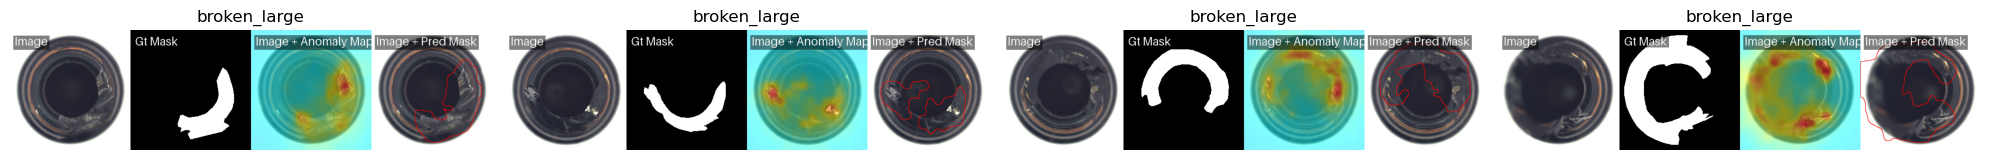

In [16]:
def show_saved_visualizations(paths, max_images=4):
    selected = paths[:max_images]
    if not selected:
        print("No saved visualization images found yet.")
        return

    fig, axes = plt.subplots(1, len(selected), figsize=(5 * len(selected), 5))
    if len(selected) == 1:
        axes = [axes]

    for ax, path in zip(axes, selected):
        image_bgr = cv2.imread(str(path))
        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        ax.imshow(image_rgb)
        ax.set_title(path.parent.name)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


show_saved_visualizations(visualization_files, max_images=4)

## Optional: Export To ONNX

ONNX export is useful later for backend inference optimization.

Keep this optional for now. If export fails, the checkpoint is still enough for continued experimentation.

In [17]:
if RUN_EXPORT_ONNX:
    export_path = engine.export(
        model=model,
        export_type=ExportType.ONNX,
        export_root=MODEL_EXPORT_DIR / "onnx",
        model_file_name=f"{MODEL_NAME}_mvtec_bottle_v1",
        input_size=IMAGE_SIZE,
        datamodule=datamodule,
    )
    print("Exported ONNX model:", export_path)
else:
    print("RUN_EXPORT_ONNX is False. Skipping ONNX export.")

RUN_EXPORT_ONNX is False. Skipping ONNX export.


## Compare With Baseline

After this notebook, compare Anomalib metrics against the baseline results from notebook 6.

Baseline metrics file:

`outputs/reports/baseline_detection_metrics.json`

Anomalib metrics file:

`outputs/reports/anomalib_padim_metrics.json`

In [18]:
baseline_metrics_path = REPORT_DIR / "baseline_detection_metrics.json"

if baseline_metrics_path.exists():
    with baseline_metrics_path.open("r", encoding="utf-8") as file:
        baseline_metrics = json.load(file)

    comparison_rows = [
        {"model": "baseline", **baseline_metrics},
        {"model": f"anomalib_{MODEL_NAME}", **metrics},
    ]
    comparison_df = pd.DataFrame(comparison_rows)
    display(comparison_df)
else:
    print("Baseline metrics file not found. Run notebook 6 first if you want comparison.")

,model,accuracy,precision,recall,f1_score,confusion_matrix,roc_auc,image_AUROC,image_F1Score,pixel_AUROC,pixel_F1Score
0,baseline,0.7711,1.0,0.6984,0.8224,"[[20, 0], [19, 44]]",0.9206,NaN,NaN,NaN,NaN
1,anomalib_padim,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.992,0.978743,0.679882


## Next Step

After this notebook works, the next notebook is:

`08_defect_classification.ipynb`

That notebook will classify defect type:

- `good`
- `broken_large`
- `broken_small`
- `contamination`

## Summary

You trained a professional anomaly detection model using Anomalib:

- verified GPU
- loaded MVTec bottle dataset
- resized images to 256 x 256
- trained PaDiM
- tested image and pixel metrics
- copied checkpoint to `models/checkpoints/`
- saved model metadata
- inspected generated heatmaps

This is the main AI model track for the project.